In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/age-gender-and-ethnicity-face-data-csv/age_gender.csv
/kaggle/input/age-and-gender-classify/input_image.jfif


In [2]:
import numpy as np 
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as L
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('../input/age-gender-and-ethnicity-face-data-csv/age_gender.csv')

## Converting pixels into numpy array
data['pixels']=data['pixels'].apply(lambda x:  np.array(x.split(), dtype="float32"))

data.head()

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,"[129.0, 128.0, 128.0, 126.0, 127.0, 130.0, 133..."
1,1,2,0,20161219222752047.jpg.chip.jpg,"[164.0, 74.0, 111.0, 168.0, 169.0, 171.0, 175...."
2,1,2,0,20161219222832191.jpg.chip.jpg,"[67.0, 70.0, 71.0, 70.0, 69.0, 67.0, 70.0, 79...."
3,1,2,0,20161220144911423.jpg.chip.jpg,"[193.0, 197.0, 198.0, 200.0, 199.0, 200.0, 202..."
4,1,2,0,20161220144914327.jpg.chip.jpg,"[202.0, 205.0, 209.0, 210.0, 209.0, 209.0, 210..."


In [26]:
!pip install yolov5 #contains yolov7.pt module file
!pip install opencv-python

#There is no such thing as YOLOv7, so you cannot install a module named "yolov7". The latest version of YOLO is YOLOv5, which you can install using the command you provided: !pip install yolov5.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.3/956.3 kB 25.8 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 73.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.5/97.5 kB 7.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.5.0-py2.py3-none-any.whl size=116949 sha256=467abeca3f121

In [27]:
import torch
from yolov5.models.experimental import attempt_load

weights = 'yolov5s.pt'  # path to YOLOv5 weights file
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = attempt_load(weights)

  0%|          | 0.00/14.1M [00:00<?, ?B/s]


Fusing layers... 
YOLOv5s summary: 270 layers, 7235389 parameters, 0 gradients


In [33]:
import cv2

# load the image
image = cv2.imread('/kaggle/input/age-and-gender-classify/input_image.jfif')

# load the pre-trained Haar Cascade classifier
face_cascade = cv2.CascadeClassifier('/kaggle/input/haarcascade-frontalface-defaultxml/haarcascade_frontalface_default.xml')

# convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# detect faces in the image
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# draw bounding boxes around the detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# save the resulting image with bounding boxes
cv2.imwrite('output_image.jpg', image)

# download the image
from IPython.display import FileLink
FileLink(r'output_image.jpg')

/kaggle/working/output_image.jpg

In [4]:
print('Total rows: {}'.format(len(data)))
print('Total columns: {}'.format(len(data.columns)))

Total rows: 23705
Total columns: 5


In [5]:
## normalizing pixels data
data['pixels'] = data['pixels'].apply(lambda x: x/255)

## calculating distributions
age_dist = data['age'].value_counts()
ethnicity_dist = data['ethnicity'].value_counts()
gender_dist = data['gender'].value_counts().rename(index={0:'Male',1:'Female'})

def ditribution_plot(x,y,name):
    fig = go.Figure([
        go.Bar(x=x, y=y)
    ])

    fig.update_layout(title_text=name)
    fig.show()

In [6]:
ditribution_plot(x=age_dist.index, y=age_dist.values, name='Age Distribution')

In [7]:
ditribution_plot(x=ethnicity_dist.index, y=ethnicity_dist.values, name='Ethnicity Distribution')

In [8]:
ditribution_plot(x=gender_dist.index, y=gender_dist.values, name='Gender Distribution')

In [9]:
X = np.array(data['pixels'].tolist())

## Converting pixels from 1D to 3D
X = X.reshape(X.shape[0],48,48,1)

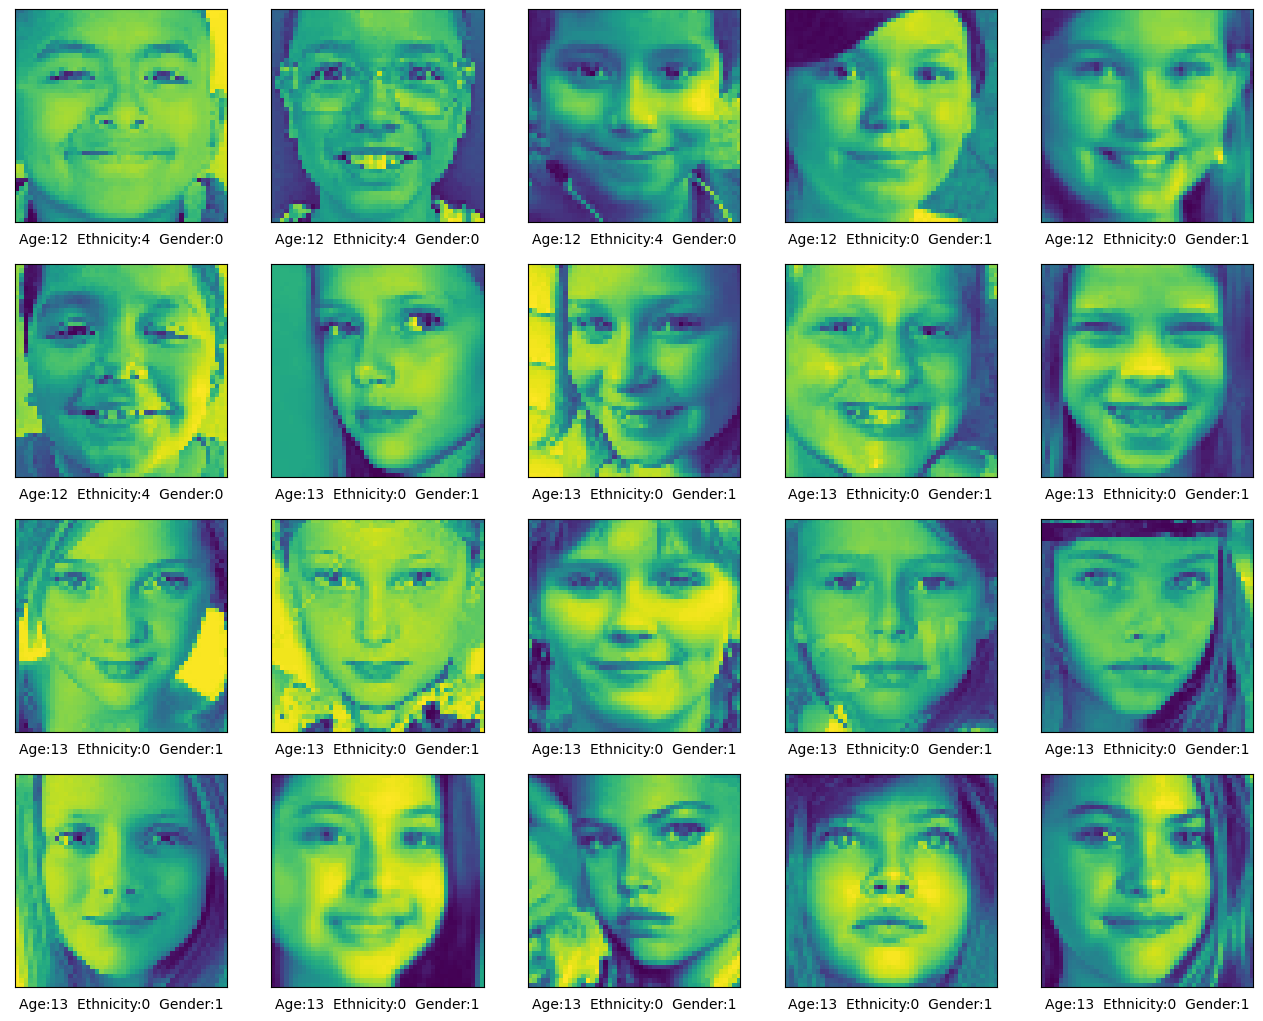

In [10]:
plt.figure(figsize=(16,16))
for i in range(1500,1520):
    plt.subplot(5,5,(i%25)+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(data['pixels'].iloc[i].reshape(48,48))
    plt.xlabel(
        "Age:"+str(data['age'].iloc[i])+
        "  Ethnicity:"+str(data['ethnicity'].iloc[i])+
        "  Gender:"+ str(data['gender'].iloc[i])
    )
plt.show()

In [11]:
y = data['gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=37
)

In [12]:
model = tf.keras.Sequential([
    L.InputLayer(input_shape=(48,48,1)),
    L.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Conv2D(64, (3, 3), activation='relu'),
    L.MaxPooling2D((2, 2)),
    L.Flatten(),
    L.Dense(64, activation='relu'),
    L.Dropout(rate=0.5),
    L.Dense(1, activation='sigmoid')
])

model.compile(optimizer='sgd',
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])


## Stop training when validation loss reach 0.2700
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_loss')<0.2700):
            print("\nReached 0.2700 val_loss so cancelling training!")
            self.model.stop_training = True
        
callback = myCallback()

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 46, 46, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 46, 46, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 23, 23, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 10, 10, 64)       0         
 2D)                                                             
                                                        

In [13]:
history = model.fit(
    X_train, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[callback]
)

Epoch 1/20
260/260 [==============================] - 32s 120ms/step - loss: 0.4998 - accuracy: 0.7572 - val_loss: 0.5924 - val_accuracy: 0.8215
Epoch 2/20
260/260 [==============================] - 31s 118ms/step - loss: 0.3808 - accuracy: 0.8305 - val_loss: 0.4020 - val_accuracy: 0.8513
Epoch 3/20
260/260 [==============================] - 31s 118ms/step - loss: 0.3380 - accuracy: 0.8517 - val_loss: 0.3503 - val_accuracy: 0.8410
Epoch 4/20
260/260 [==============================] - 31s 119ms/step - loss: 0.3208 - accuracy: 0.8588 - val_loss: 0.3200 - val_accuracy: 0.8648
Epoch 5/20
260/260 [==============================] - 31s 120ms/step - loss: 0.3036 - accuracy: 0.8679 - val_loss: 0.3092 - val_accuracy: 0.8648
Epoch 6/20
260/260 [==============================] - 32s 123ms/step - loss: 0.2933 - accuracy: 0.8712 - val_loss: 0.3020 - val_accuracy: 0.8707
Epoch 7/20
260/260 [==============================] - 31s 121ms/step - loss: 0.2802 - accuracy: 0.8791 - val_loss: 0.3418 - val_ac

In [14]:
fig = px.line(
    history.history, y=['loss', 'val_loss'],
    labels={'index': 'epoch', 'value': 'loss'}, 
    title='Training History')
fig.show()

In [15]:
loss, acc = model.evaluate(X_test,y_test,verbose=0)
print('Test loss: {}'.format(loss))
print('Test Accuracy: {}'.format(acc))

Test loss: 0.2510092854499817
Test Accuracy: 0.8865030407905579


In [16]:
y = data['ethnicity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=37
)

In [17]:
model = tf.keras.Sequential([
    L.InputLayer(input_shape=(48,48,1)),
    L.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    L.MaxPooling2D((2, 2)),
    L.Conv2D(64, (3, 3), activation='relu'),
    L.MaxPooling2D((2, 2)),
    L.Flatten(),
    L.Dense(64, activation='relu'),
    L.Dropout(rate=0.5),
    L.Dense(5)
])

model.compile(optimizer='rmsprop',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


## Stop training when validation accuracy reach 79%
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy')>0.790):
            print("\nReached 79% val_accuracy so cancelling training!")
            self.model.stop_training = True
        
callback = myCallback()


model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 46, 46, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 23, 23, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 10, 10, 64)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 6400)              0         
                                                                 
 dense_2 (Dense)             (None, 64)               

In [18]:
history = model.fit(
    X_train, y_train, epochs=16, validation_split=0.1, batch_size=64, callbacks=[callback]
)

Epoch 1/16
260/260 [==============================] - 25s 95ms/step - loss: 1.3224 - accuracy: 0.4799 - val_loss: 1.0456 - val_accuracy: 0.6187
Epoch 2/16
260/260 [==============================] - 25s 95ms/step - loss: 1.0764 - accuracy: 0.6016 - val_loss: 0.8853 - val_accuracy: 0.6988
Epoch 3/16
260/260 [==============================] - 25s 95ms/step - loss: 0.9798 - accuracy: 0.6508 - val_loss: 0.8283 - val_accuracy: 0.7117
Epoch 4/16
260/260 [==============================] - 25s 95ms/step - loss: 0.9179 - accuracy: 0.6763 - val_loss: 0.8106 - val_accuracy: 0.7193
Epoch 5/16
260/260 [==============================] - 24s 93ms/step - loss: 0.8676 - accuracy: 0.6967 - val_loss: 0.7371 - val_accuracy: 0.7372
Epoch 6/16
260/260 [==============================] - 25s 94ms/step - loss: 0.8310 - accuracy: 0.7094 - val_loss: 0.7229 - val_accuracy: 0.7463
Epoch 7/16
260/260 [==============================] - 25s 95ms/step - loss: 0.7983 - accuracy: 0.7209 - val_loss: 0.6854 - val_accuracy:

In [19]:
fig = px.line(
    history.history, y=['loss', 'val_loss'],
    labels={'index': 'epoch', 'value': 'loss'}, 
    title='Training History')
fig.show()

In [20]:
loss, acc = model.evaluate(X_test,y_test,verbose=0)
print('Test loss: {}'.format(loss))
print('Test Accuracy: {}'.format(acc))

Test loss: 0.6255689859390259
Test Accuracy: 0.7896856069564819


In [21]:
y = data['age']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.22, random_state=37
)

In [22]:
model = tf.keras.Sequential([
    L.InputLayer(input_shape=(48,48,1)),
    L.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Conv2D(64, (3, 3), activation='relu'),
    L.MaxPooling2D((2, 2)),
    L.Conv2D(128, (3, 3), activation='relu'),
    L.MaxPooling2D((2, 2)),
    L.Flatten(),
    L.Dense(64, activation='relu'),
    L.Dropout(rate=0.5),
    L.Dense(1, activation='relu')
])

sgd = tf.keras.optimizers.SGD(momentum=0.9)

model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mae'])


## Stop training when validation loss reach 110
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_loss')<110):
            print("\nReached 110 val_loss so cancelling training!")
            self.model.stop_training = True
        
callback = myCallback()


model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 46, 46, 32)        320       
                                                                 
 batch_normalization_1 (Batc  (None, 46, 46, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 23, 23, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 21, 21, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 10, 10, 64)       0         
 2D)                                                             
                                                      

In [23]:
history = model.fit(
    X_train, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[callback]
)

Epoch 1/20
260/260 [==============================] - 38s 141ms/step - loss: 342.4527 - mae: 14.0892 - val_loss: 1143.6047 - val_mae: 28.0924
Epoch 2/20
260/260 [==============================] - 36s 138ms/step - loss: 205.3395 - mae: 10.8122 - val_loss: 580.0947 - val_mae: 18.7912
Epoch 3/20
260/260 [==============================] - 36s 138ms/step - loss: 171.2763 - mae: 9.7631 - val_loss: 341.0449 - val_mae: 14.0558
Epoch 4/20
260/260 [==============================] - 36s 138ms/step - loss: 159.9265 - mae: 9.3932 - val_loss: 121.4076 - val_mae: 8.4353
Epoch 5/20
260/260 [==============================] - 36s 140ms/step - loss: 145.6336 - mae: 8.9490 - val_loss: 142.1274 - val_mae: 8.5739
Epoch 6/20
260/260 [==============================] - 36s 137ms/step - loss: 134.8248 - mae: 8.5929 - val_loss: 164.1516 - val_mae: 9.3964
Epoch 7/20
260/260 [==============================] - ETA: 0s - loss: 126.0306 - mae: 8.3111
Reached 110 val_loss so cancelling training!
260/260 [=============

In [24]:
fig = px.line(
    history.history, y=['loss', 'val_loss'],
    labels={'index': 'epoch', 'value': 'loss'}, 
    title='Training History')
fig.show()

In [25]:
mse, mae = model.evaluate(X_test,y_test,verbose=0)
print('Test Mean squared error: {}'.format(mse))
print('Test Mean absolute error: {}'.format(mae))

Test Mean squared error: 102.0644302368164
Test Mean absolute error: 7.533812046051025
